In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.
from jaxopt import Bisection, Broyden, ScipyBoundedMinimize
import blackjax

import gpjax as gpx
from tensorflow_probability.substrates import jax as tfp
from tensorflow_probability.substrates.jax.mcmc import sample_halton_sequence

import matplotlib.pyplot as plt
import seaborn as sns


/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


In [2]:
#===========================================
# G and K model
#===========================================

def simulate(_rngkey, num, theta, c0=0.8):
    samples = tfp.distributions.Normal(0.0, 1.0).sample(sample_shape=(num,),seed=_rngkey)
    g_transform = 1.0 + c0 * jnp.tanh( 0.5 * theta[2] * samples ) 
    h_transform = samples * ( 1.0 + samples**2 ) ** theta[3]
    return theta[0] + theta[1] * g_transform * h_transform

def quantile(u, theta):
    zu = jsp.stats.norm.ppf(u)
    c0 = 0.8
    c1 = 1.0 + c0 * jnp.tanh(0.5*theta[2]*zu)
    c2 = ( 1.0 + zu**2 )**theta[3]
    return theta[0] + theta[1] * zu * c1 * c2

root_finding = Bisection(optimality_fun=lambda u, x, theta: quantile(u, theta) - x, lower=0.0, upper=1.0, check_bracket=False)
inv_quantile = lambda x, theta: root_finding.run(x=x, theta=theta).params
jac_quantile = jax.jacrev(quantile, argnums=0)

inv_quantile_vmap = jax.vmap(inv_quantile, in_axes=(0,None))
jac_quantile_vmap = jax.vmap(jac_quantile, in_axes=(0,None))

def logpdf_vmap(X, theta):
    inv_Q = inv_quantile_vmap(X, theta)
    jac_Q = jac_quantile_vmap(inv_Q, theta)
    log_Q = - jnp.log( jac_Q )
    return jnp.nan_to_num(log_Q, nan=-1000, posinf=1000, neginf=-1000)


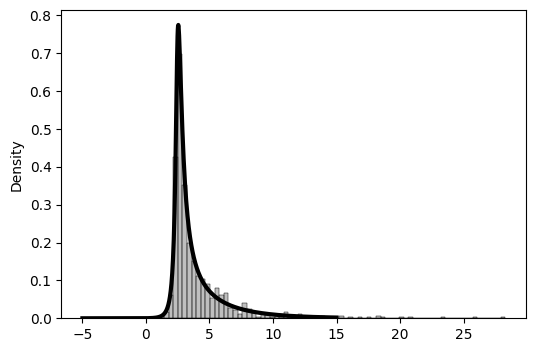

In [3]:
#===========================================
# Simulation
#===========================================

a = 3.0
b = 1.0
g = 2.0
k = 0.5
theta_0 = jnp.array([a, b, g, k])

key = jrandom.key(0)
key, _key = jax.random.split(key)
data = simulate(_key, 1000, theta_0)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plt_x = jnp.linspace(-5, 15, 1000)
sns.lineplot(x=plt_x, y=jnp.exp(logpdf_vmap(plt_x, theta_0)), color="black", linewidth=3, ax=ax)
sns.histplot(x=data, stat="density", alpha=0.5, color="gray", ax=ax)
plt.show()

with open('Data/data.npy', 'wb') as f:
    jnp.save(f, data)
